<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/compte_rendu_du_TP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objectifs

• Calculer et interpréter les valeurs propres (variance expliquée)

• Comprendre les composantes principales

• Analyser le cercle des corrélations

• Interpréter la projection des individus

• Exploiter les contributions et la qualité de représentation (cos2)

In [1]:
#Préparation de l’environnement
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#Jeu de données (Données fictives) : performance d’étudiants
data = {
"TP": [12, 15, 9, 18, 14, 10],
"Examen": [11, 16, 8, 17, 13, 9],
"Projet": [13, 14, 10, 18, 15, 11],
"Assiduite": [90, 95, 70, 98, 85, 75]
}
df = pd.DataFrame(data)
df.index = [f"Etudiant{i+1}" for i in range(len(df))]
print(df)

           TP  Examen  Projet  Assiduite
Etudiant1  12      11      13         90
Etudiant2  15      16      14         95
Etudiant3   9       8      10         70
Etudiant4  18      17      18         98
Etudiant5  14      13      15         85
Etudiant6  10       9      11         75


In [3]:
#1. Standardisation des données (obligatoire)
#L’ACP est sensible aux unités → centrage-réduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [4]:
#2. ACP – Calcul des composantes principales
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [5]:
#3. Valeurs propres & variance expliquée
#• Valeurs propres
eigenvalues = pca.explained_variance_
print("Valeurs propres :", eigenvalues)

Valeurs propres : [4.54100717e+00 1.77794851e-01 8.01478077e-02 1.05017366e-03]


In [6]:
#• Variance expliquée (%)
explained_variance = pca.explained_variance_ratio_ * 100
print("Variance expliquée (%) :", explained_variance)

Variance expliquée (%) : [9.46043160e+01 3.70405939e+00 1.66974599e+00 2.18786179e-02]


In [7]:
#• Variance cumulée
cumulative_variance = np.cumsum(explained_variance)
print("Variance cumulée (%) :", cumulative_variance)

Variance cumulée (%) : [ 94.604316    98.30837539  99.97812138 100.        ]


In [8]:
#4. Composantes principales (axes factoriels)
components = pd.DataFrame(
pca.components_,
columns=df.columns,
index=[f"PC{i+1}" for i in range(len(df.columns))]
)
print(components)

           TP    Examen    Projet  Assiduite
PC1  0.511019  0.503859  0.495379   0.489475
PC2 -0.246215  0.160682 -0.624443   0.723623
PC3  0.183747  0.727040 -0.448703  -0.486124
PC4  0.802792 -0.437859 -0.404149   0.021624


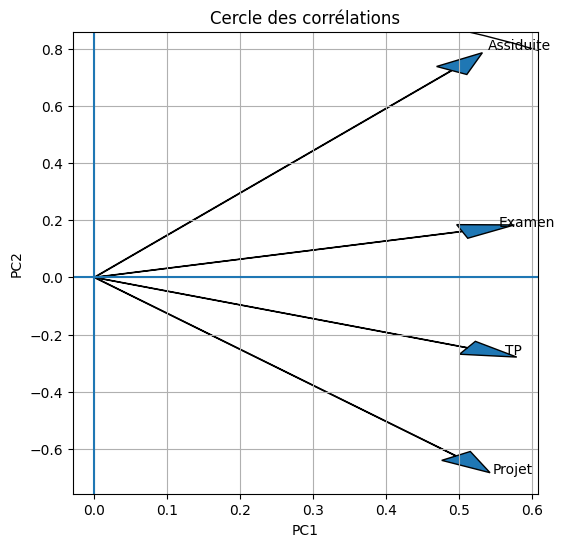

In [10]:
#5. Cercle des corrélations
plt.figure(figsize=(6,6))
for i in range(len(df.columns)):

  plt.arrow(0, 0,
  components.iloc[0, i],
  components.iloc[1, i],
  head_width=0.05)
  plt.text(components.iloc[0, i]*1.1,
  components.iloc[1, i]*1.1,
  df.columns[i])
circle = plt.Circle((0,0), 1, fill=False)
plt.gca().add_artist(circle)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle des corrélations")
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.show()

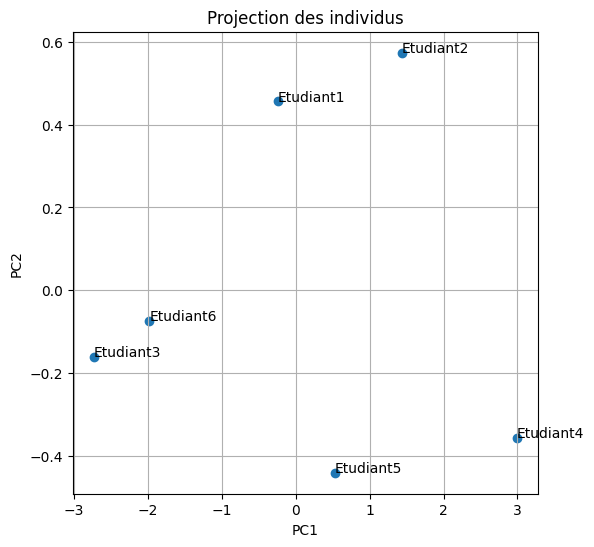

In [11]:
#6. Projection des individus
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
for i, txt in enumerate(df.index):
  plt.annotate(txt, (X_pca[i,0], X_pca[i,1]))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection des individus")
plt.grid()
plt.show()

In [12]:
#7. Contributions des variables
#• Contribution à PC1 et PC2
contrib = components.T ** 2
print(contrib)
#Lecture :
#• Forte contribution = variable importante dans l’axe
#• Somme des contributions ≈ 1 par axe

                PC1       PC2       PC3       PC4
TP         0.261140  0.060622  0.033763  0.644475
Examen     0.253874  0.025819  0.528587  0.191721
Projet     0.245400  0.389929  0.201334  0.163336
Assiduite  0.239586  0.523630  0.236317  0.000468


In [13]:
#8. Qualité de représentation (cos2) des individus
cos2 = (X_pca ** 2) / np.sum(X_pca ** 2, axis=1).reshape(-1,1)
cos2_df = pd.DataFrame(cos2[:, :2], index=df.index, columns=["PC1", "PC2"])
print(cos2_df)

                PC1       PC2
Etudiant1  0.120295  0.417774
Etudiant2  0.814877  0.129552
Etudiant3  0.993160  0.003419
Etudiant4  0.985542  0.013978
Etudiant5  0.583024  0.408831
Etudiant6  0.998435  0.001374
